In [36]:
import pathlib
import random
import copy
import numpy as np
import torch
import torchvision
from captum.attr import *
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import yaml
import argparse
from data.data_loader import load_eeg_data, get_sliding_window_data, create_dataloader
import os
import mne
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

from sliced_wasserstein import sliced_wasserstein_distance



In [38]:
CFG_YAML = """
wandb:
 key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model:
dataset:
 data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
 #file_name: subject_{:03d}_preprocessed_combined_py.fif
 file_name: subject_{:03d}_preprocessed_combined_py.fif
 exclude_timepoints: 100
 subject_index: 1
 test_subject_indices: [1,2,13,24,26,27,29,34,35,41, 42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88,92,102]
 #test_subject_indices: [2]
training:
 training_start_len: 100
 pretrain_epochs: 100
 pretrain_lr: 0.0001
 val_window_len: 1
 epochs_per_window: 10
 num_warmup_epochs: 5
 num_epochs: 800
 slide_step: 1
 num_warmup_epochs_per_window: 0
 lr: 0.005 #maybe change back to 0.0001
 nll_beta: 0.001
 num_warmup_epochs: 0
 batch_size: 50 #better to use 50
 random_seed: 42
 precision: bf16
 kde_lambda: 0.5
 finetune_entire_model: true # Set to true to finetune the entire model, false for transformer only
exp_name: S4_S4EEGNet_ema
"""


def load_config():
    cfg = OmegaConf.create(yaml.safe_load(CFG_YAML))
    cfg.exp_name = f"{cfg.exp_name}_subject_{cfg.dataset.subject_index}"
    return cfg

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--update_conf", nargs="*", help="Updates to the configuration in the form of key=value pairs", default=[])
    parser.add_argument("-f", "--fff", help="A dummy argument to handle IPython's default argument", default="1")
    return parser.parse_args()

def update_config(cfg, cli_args):
    for update in cli_args.update_conf:
        key, value = update.split("=")
        try:
            value = eval(value)
        except:
            pass
        OmegaConf.update(cfg, key, value, force_add=True)
    cfg.exp_name = cfg.exp_name + "_" + "_".join(cli_args.update_conf)
    print(OmegaConf.to_yaml(cfg))
    return cfg


def save_config(cfg):
    os.makedirs("conf/sweeps", exist_ok=True)
    os.makedirs("exp/withinsubs", exist_ok=True)
    with open(f"conf/sweeps/withinsubs_{cfg.exp_name}.yaml", "w") as f:
        f.write(OmegaConf.to_yaml(cfg))


In [2]:
power_perturb_dir = "perturb_power_OOD"
phase_perturb_dir = "perturb_phase_OOD"

In [3]:
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'x-large',
          'figure.titlesize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

In [74]:
freq_bands = {"delta" : (0.5, 4),
                "theta": (4, 8),
              "alpha": (8, 12),
              "beta": (12, 30),
              "gamma": (30, 45)}
#phase_perturbationss = [0.2,0.5,2,3,5,10]
phase_perturbations = np.arange(45, 316, 45)
amplification_factors = [0.5,0.75,1.5, 2,3]

In [5]:
def load_subjet_data(subject_index):
    subject_dict_power = {}
    subject_dict_phase = {}
    for freq_band,_ in freq_bands.items():
        subject_dict_power[freq_band] = {}
        subject_dict_phase[freq_band] = {}
        for amp_factor in amplification_factors:
            power_file = "power_perturbation_results_{}_{}_{}.npy".format(subject_index, freq_band, amp_factor)
            power_file = os.path.join(power_perturb_dir, power_file)
            subject_dict_power[freq_band][amp_factor] = np.load(power_file, allow_pickle=True)
        
        for phase_shift in phase_perturbations:
            phase_file = "phase_perturbation_results_{}_{}_{}°.npy".format(subject_index, freq_band, phase_shift)
            phase_file = os.path.join(phase_perturb_dir, phase_file)
            subject_dict_phase[freq_band][phase_shift] = np.load(phase_file, allow_pickle=True) 

    return subject_dict_power, subject_dict_phase
            
     
          

In [6]:
power_data_2, phase_data_2 = load_subjet_data(2)

In [39]:
import matplotlib.pyplot as plt


#axs = axs.ravel()

def plot_perturbation_metrics(power_data, phase_data, subject_index):
    fig, axs = plt.subplots(2,5, figsize=(13, 5))
    fig.tight_layout()
    fig.suptitle(f'Subject {subject_index} Perturbation Metrics')
    for idx, x in enumerate(zip(power_data.items(), phase_data.items())):
        band, data_power = x[0]
        _, data_phase = x[1]

        swd_values_power = [data_power[factor].item()["swd_500"] for factor in amplification_factors]
        c2st_values_power = [data_power[factor].item()['c2st_rf'] for factor in amplification_factors]
        
        swd_values_phase = [data_phase[shift].item()["swd_500"] for shift in phase_perturbations]
        c2st_values_phase = [data_phase[shift].item()['c2st_rf'] for shift in phase_perturbations]
        
        axs[0,idx].plot(amplification_factors, swd_values_power, 'o-', label='swd_500')
        axs[0,idx].plot(amplification_factors, c2st_values_power, 's-', label='c2st_rf')

        axs[1,idx].plot(phase_perturbations, swd_values_phase, 'o-', label='swd_500')
        axs[1,idx].plot(phase_perturbations, c2st_values_phase, 's-', label='c2st_rf')
        
        # Add horizontal lines
        axs[0,idx].axhline(y=0.4, color='red', linestyle='--', alpha=0.5)
        axs[0,idx].axhline(y=0.6, color='red', linestyle='--', alpha=0.5)
        axs[1,idx].axhline(y=0.4, color='red', linestyle='--', alpha=0.5)
        axs[1,idx].axhline(y=0.6, color='red', linestyle='--', alpha=0.5)
        
        axs[0,idx].set_title(f'{band} band')
        axs[0,idx].set_xlabel('Amplification Factor')
        #axs[0,idx].set_ylabel('Metric Value')
        axs[0,idx].legend()
        axs[0,idx].grid(True)

        #axs[1,idx].set_title(f'{band} band')
        axs[1,idx].set_xlabel('Phase Perturbation (°)')
        #axs[1,idx].set_ylabel('Metric Value')
        axs[1,idx].legend()



In [40]:
#for subject_index in [1,2,13,24,26,27,29,34,35,41, 42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88]:
#    power_data, phase_data = load_subjet_data(subject_index)
#    plot_perturbation_metrics(power_data, phase_data, subject_index)

In [28]:
import torch
from sliced_wasserstein import sliced_wasserstein_distance

In [29]:
def compute_baseline_swd(all_epochs, device, seed=42):
    """
    Compute baseline Sliced Wasserstein Distance between two random splits of the data
    
    Parameters:
        all_epochs: numpy array of epochs data
        device: torch device to use for computation
        seed: random seed for reproducibility
        
    Returns:
        float: sliced Wasserstein distance between the two splits
    """
    np.random.seed(seed)
    indices = np.arange(all_epochs.shape[0])
    np.random.shuffle(indices)
    split = int(0.5 * len(indices))
    
    # Ensure equal split sizes
    indices_1 = indices[:split]
    indices_2 = indices[split:]
    min_size = min(len(indices_1), len(indices_2))
    indices_1 = indices_1[:min_size]
    indices_2 = indices_2[:min_size]

    # Reshape and convert to tensors
    samples_1 = all_epochs[indices_1].reshape(len(indices_1), -1)
    samples_2 = all_epochs[indices_2].reshape(len(indices_2), -1)
    samples_1 = torch.tensor(samples_1, dtype=torch.float32).to(device)
    samples_2 = torch.tensor(samples_2, dtype=torch.float32).to(device)
    
    return sliced_wasserstein_distance(samples_1, samples_2, device=device, num_projections=500)

In [30]:
subjects = [1,2,13,24,26,27,29,34,35,41,42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88]

In [43]:
# Assuming CUDA is available, otherwise use 'cpu'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize list to store baseline SWD values
baseline_swd_values = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_shape_st = (60, 900)
# Compute baseline SWD for each subject
for subject in subjects:
    cfg = load_config()

    subject_index = subject
    cfg.dataset.subject_index = subject_index
    cfg.exp_name = f"S4_S4EEGNet_ema_100_cal_py_{cfg.dataset.subject_index}"

    all_epochs, labels_raw, _, _, _, _, _, ch_names = load_eeg_data(cfg)
    all_epochs = all_epochs[150:]
    labels_raw = labels_raw[150:]

    
    # Use the first frequency band and first amplification factor as baseline data

    

    
    # Compute baseline SWD
    baseline_swd = compute_baseline_swd(all_epochs, device)
    baseline_swd_values.append(baseline_swd)

# Plot histogram of baseline SWD values
#plt.figure(figsize=(10, 6))
#plt.hist(baseline_swd_values, bins=20)
#plt.title('Distribution of Baseline SWD across Subjects')
#plt.xlabel('Sliced Wasserstein Distance')
#plt.ylabel('Count')
#plt.grid(True)

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_001_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/OOD_perturbation_analysis/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_001_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
510 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_002_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/OOD_perturbation_analysis/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_002_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
721 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_013_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


...

Adding metadata with 1 columns
760 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_086_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/OOD_perturbation_analysis/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_086_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
736 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_088_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/OOD_perturbation_analysis/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_088_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
608 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


In [47]:
baseline_swd_values = torch.tensor(baseline_swd_values)

In [48]:
baseline_swd_values

tensor([0.1857, 0.2590, 0.1774, 3.6148, 0.1774, 0.1816, 0.1865, 1.0917, 0.4109,
        0.1923, 0.2193, 1.2464, 0.2479, 0.1419, 0.1802, 0.2075, 0.1745, 0.1744,
        0.2250, 0.5517, 0.1555, 0.1681, 0.1590, 0.2105, 0.1601, 0.5019, 0.2802,
        0.1789, 0.1999, 0.1496])

In [55]:
median_swd = torch.median(baseline_swd_values)
std_swd = torch.std(baseline_swd_values)

In [86]:
mean_swd = torch.mean(baseline_swd_values)

In [56]:
median_swd

tensor(0.1865)

In [57]:
std_swd

tensor(0.6601)

In [50]:
mean_swd

tensor(0.4003)

In [73]:
freq_bands

{'delta': (0.5, 4), 'alpha': (8, 12), 'beta': (12, 30), 'gamma': (30, 45)}

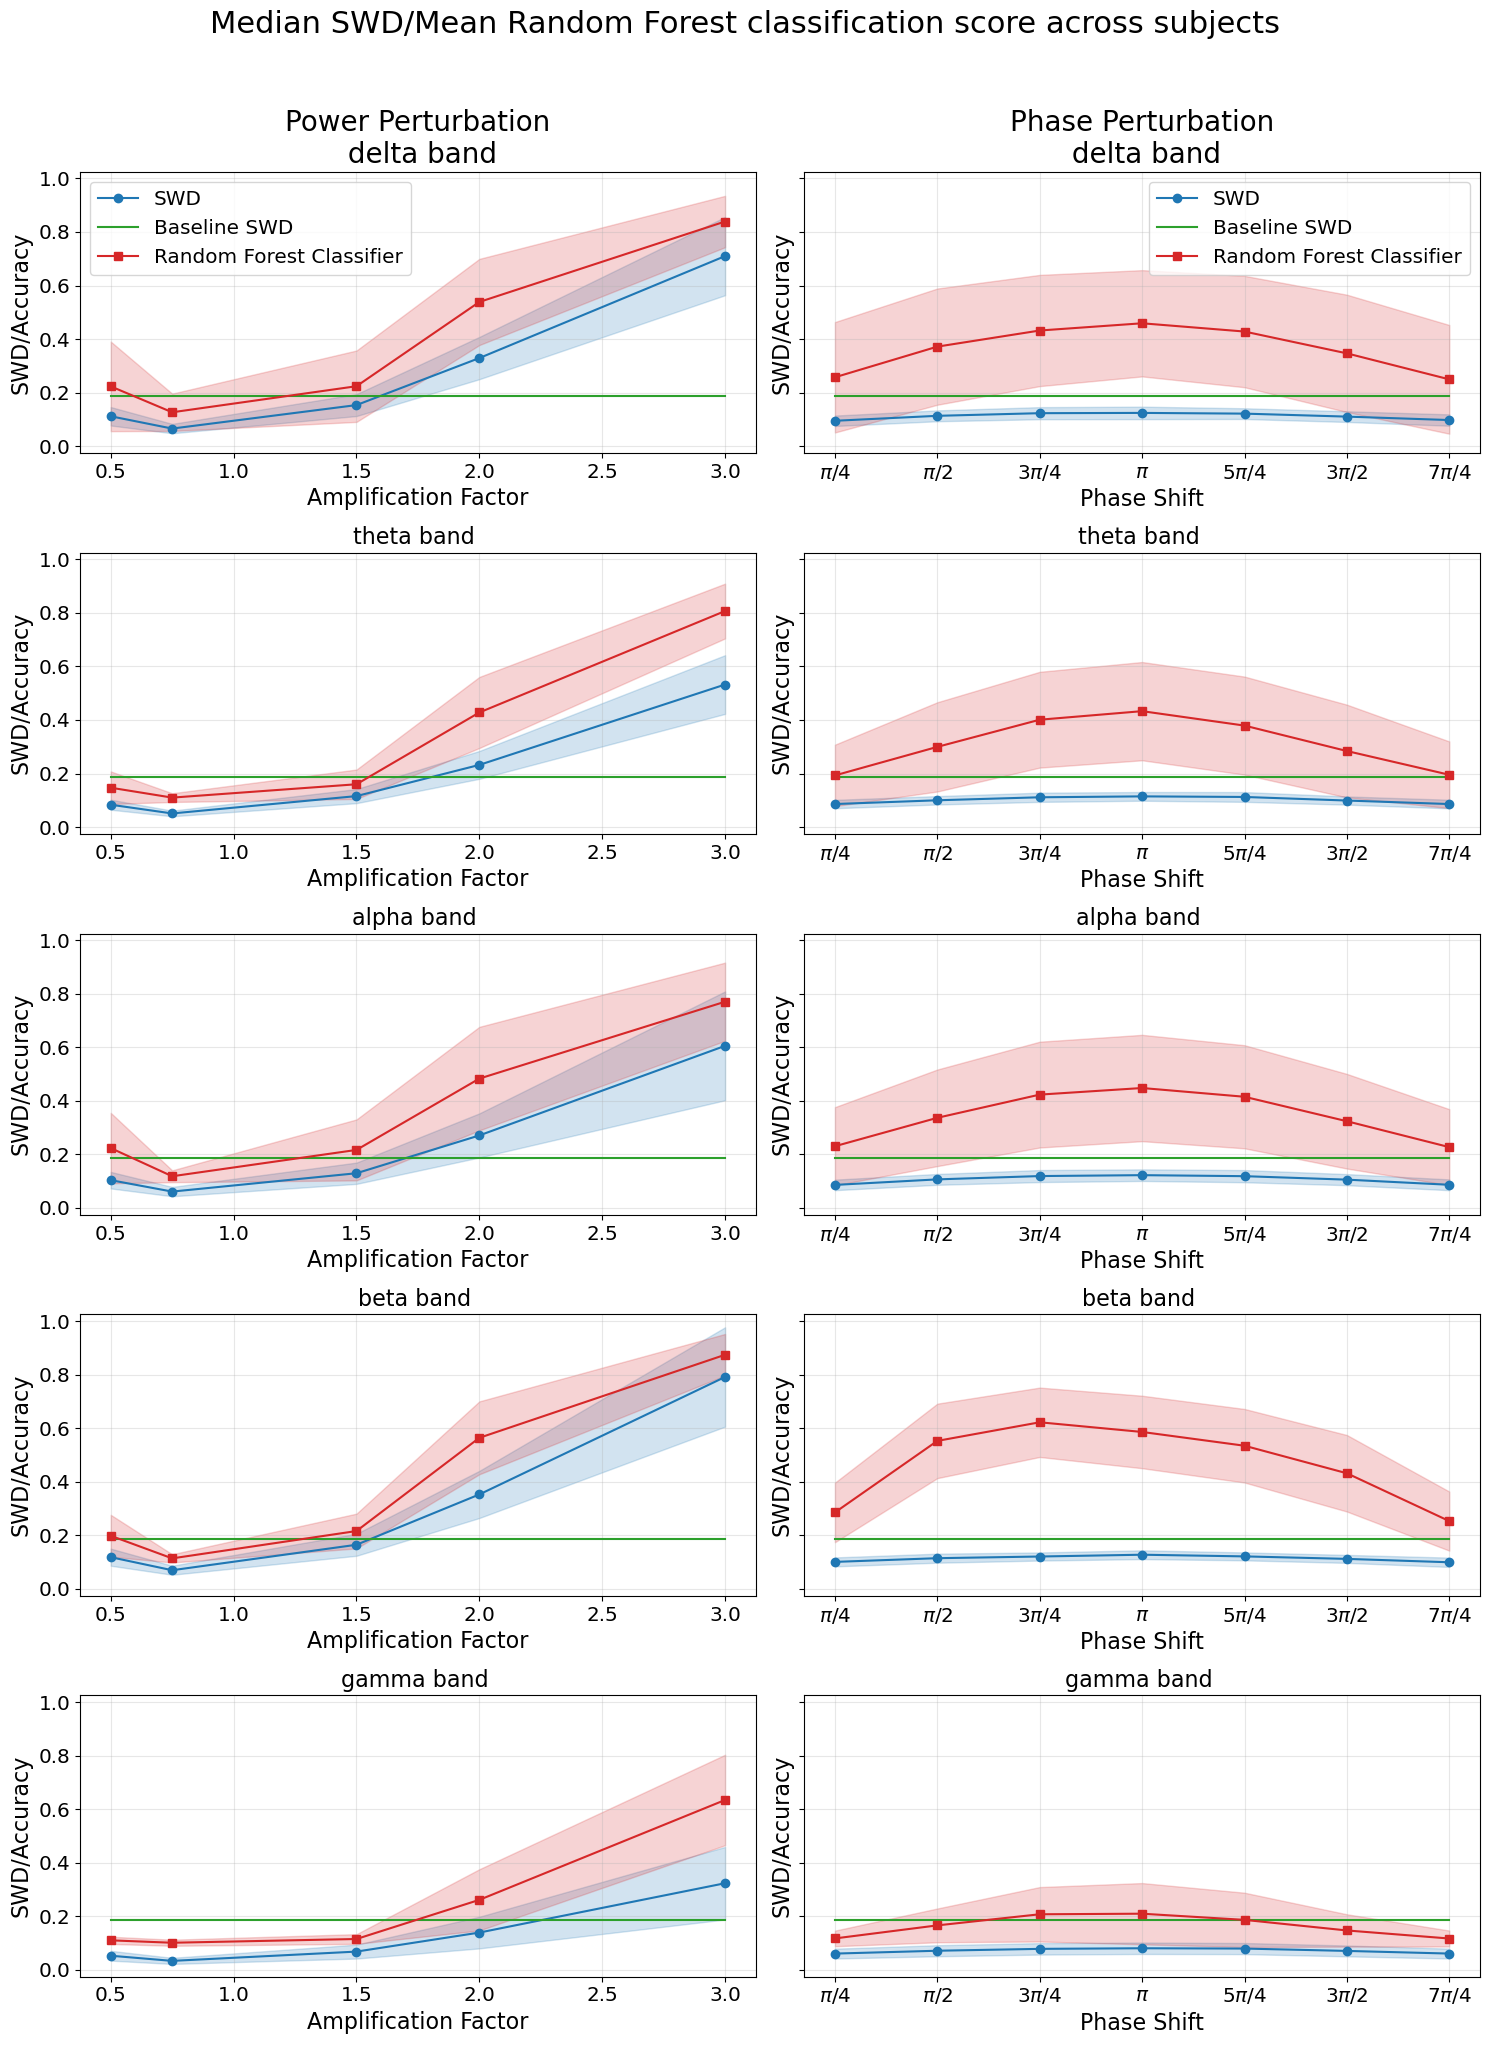

In [92]:
# First, let's gather all subjects' data

# Initialize dictionaries to store metrics for each subject
power_metrics = {band: {factor: {'swd': [], 'c2st': []} for factor in amplification_factors} 
                for band in freq_bands.keys()}
phase_metrics = {band: {shift: {'swd': [], 'c2st': []} for shift in phase_perturbations} 
                for band in freq_bands.keys()}

# Collect data from all subjects
for subject in subjects:
    power_data, phase_data = load_subjet_data(subject)
    for band in freq_bands.keys():
        for factor in amplification_factors:
            power_metrics[band][factor]['swd'].append(power_data[band][factor].item()['swd_500'])
            power_metrics[band][factor]['c2st'].append(power_data[band][factor].item()['c2st_rf'])
        for shift in phase_perturbations:
            phase_metrics[band][shift]['swd'].append(phase_data[band][shift].item()['swd_500'])
            phase_metrics[band][shift]['c2st'].append(phase_data[band][shift].item()['c2st_rf'])

# Create plots
fig, axs = plt.subplots(len(freq_bands), 2, figsize=(15, 4*len(freq_bands)), sharey=True)
fig.suptitle('Median SWD/Mean Random Forest classification score across subjects', y=1.02, fontsize=22)
fig.tight_layout()

# Define colors with good contrast
swd_color = '#1f77b4'  # Deep blue
c2st_color = '#d62728'  # Red
baseline_color = '#2ca02c'  # Green

# Add a single baseline label for the legend
baseline_added = False

for idx, band in enumerate(freq_bands.keys()):
    # Power perturbation plot
    swd_medians = [np.median(power_metrics[band][factor]['swd']) for factor in amplification_factors]
    swd_mad = [np.median(np.abs(np.array(power_metrics[band][factor]['swd']) - np.median(power_metrics[band][factor]['swd']))) for factor in amplification_factors]
    c2st_means = [np.mean(power_metrics[band][factor]['c2st']) for factor in amplification_factors]
    c2st_std = [np.std(power_metrics[band][factor]['c2st']) for factor in amplification_factors]
    
    axs[idx,0].plot(amplification_factors, swd_medians, 'o-', label='SWD', color=swd_color)
    if not baseline_added:
        axs[idx,0].plot(amplification_factors, [median_swd]*len(amplification_factors), 
                       color=baseline_color, label='Baseline SWD')
    else:
        axs[idx,0].plot(amplification_factors, [median_swd]*len(amplification_factors), 
                       color=baseline_color, label='_nolegend_')
    axs[idx,0].fill_between(amplification_factors, 
                           np.array(swd_medians) - np.array(swd_mad),
                           np.array(swd_medians) + np.array(swd_mad),
                           alpha=0.2, color=swd_color)
    
    axs[idx,0].plot(amplification_factors, c2st_means, 's-', label='Random Forest Classifier', color=c2st_color)
    axs[idx,0].fill_between(amplification_factors,
                           np.array(c2st_means) - np.array(c2st_std),
                           np.array(c2st_means) + np.array(c2st_std),
                           alpha=0.2, color=c2st_color)
    
    # Phase perturbation plot
    swd_medians = [np.median(phase_metrics[band][shift]['swd']) for shift in phase_perturbations]
    swd_mad = [np.median(np.abs(np.array(phase_metrics[band][shift]['swd']) - np.median(phase_metrics[band][shift]['swd']))) for shift in phase_perturbations]
    c2st_means = [np.mean(phase_metrics[band][shift]['c2st']) for shift in phase_perturbations]
    c2st_std = [np.std(phase_metrics[band][shift]['c2st']) for shift in phase_perturbations]
    
    phase_perturbations_rad = ["$\pi/4$", "$\pi/2$", "$3\pi/4$", "$\pi$", "$5\pi/4$", "$3\pi/2$", "$7\pi/4$"]

    axs[idx,1].plot(phase_perturbations, swd_medians, 'o-', label='SWD', color=swd_color)
    if not baseline_added:
        axs[idx,1].plot(phase_perturbations, [median_swd]*len(phase_perturbations), 
                       color=baseline_color, label='Baseline SWD')
    else:
        axs[idx,1].plot(phase_perturbations, [median_swd]*len(phase_perturbations), 
                       color=baseline_color, label='_nolegend_')
    axs[idx,1].fill_between(phase_perturbations,
                           np.array(swd_medians) - np.array(swd_mad),
                           np.array(swd_medians) + np.array(swd_mad),
                           alpha=0.2, color=swd_color)
    axs[idx,1].set_xticks(phase_perturbations)
    axs[idx,1].set_xticklabels(phase_perturbations_rad)
    
    axs[idx,1].plot(phase_perturbations, c2st_means, 's-', label='Random Forest Classifier', color=c2st_color)
    axs[idx,1].fill_between(phase_perturbations,
                           np.array(c2st_means) - np.array(c2st_std),
                           np.array(c2st_means) + np.array(c2st_std),
                           alpha=0.2, color=c2st_color)
    
    if idx == 0:
        axs[idx,0].set_title(f'Power Perturbation\n {band} band', fontsize=20)
        axs[idx,1].set_title(f'Phase Perturbation\n {band} band', fontsize=20)
    else:
        axs[idx,0].set_title(f'{band} band ', fontsize=16)
        axs[idx,1].set_title(f'{band} band ', fontsize=16)
    
    axs[idx,0].set_xlabel('Amplification Factor', fontsize=16)
    axs[idx,0].set_ylabel('SWD/Accuracy', fontsize=16)
    axs[idx,0].grid(True, alpha=0.3)
    if idx == 0:  # Only show legend for the first row
        axs[idx,0].legend()
    
    axs[idx,1].set_xlabel('Phase Shift', fontsize=16)
    axs[idx,1].set_ylabel('SWD/Accuracy', fontsize=16)
    axs[idx,1].grid(True, alpha=0.3)
    if idx == 0:  # Only show legend for the first row
        axs[idx,1].legend()
    
    baseline_added = True

plt.tight_layout()


In [ ]:
plot_metrics(power_metrics, amplification_factors, band, axs[idx,0], use_median)

In [ ]:
plot_perturbation_metrics(power_data_2, phase_data_2, freq_bands, amplification_factors, phase_perturbations)

In [93]:
fig.savefig('OOD_perturbation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

keep in mind these are the results when all channels are perturned simulateneously. try getting some results when perturbing channels individually instead

FOr phase perturbation SWD is largest for a phase shift of 180° which makes sense, but RF probably has problems which is why classifier performs the worst for this phase-shift

# OOD analysis from model uncertainty

## channelwise

In [ ]:
data_path_og = "/home/marco/Documents/GitHub/tms_eeg_decoding/subject_interpretability"
def load_original_uncertainty(subject_index=2):
    data_file = os.path.join(data_path_og, f"subject_{subject_index}_results.pkl")
    data = np.load(data_file, allow_pickle=True)
    #print(data.keys())
    return data["uncertainties"]


In [116]:
power_data_perturbed_path = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/perturbed_predictions"
phase_data_perturbed_path = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_phase/perturbed_predictions"
def load_perturbed_uncertainty_channelwise(subject_index=2):
    subject_uncertainties = {}
       
    power_file = os.path.join(power_data_perturbed_path, f"subject_{subject_index}_perturbed_predictions.npy")

    #subject_uncertainties["phase"] = {}
    for freq_band, _ in freq_bands.items():
        subject_uncertainties[freq_band] = {}
        #subject_uncertainties["phase"][freq_band] = {}
        for amp_factor in amplification_factors:
            power_file = os.path.join(power_data_perturbed_path, f"perturbed_prediction_dict_{freq_band}_channel_amp_factor_{amp_factor}_subject_{subject_index}.npy")

            subject_uncertainties[freq_band][amp_factor] = np.load(power_file, allow_pickle=True).item()
        #for phase_shift in phase_perturbations:
        #    phase_file = os.path.join(phase_data_perturbed_path, f"perturbed_prediction_dict_{freq_band}_channel_wise_phase_shift_{phase_shift}°_subject_{subject_index}.npy")
        #    subject_uncertainties["phase"][freq_band][phase_shift] = np.load(phase_file, allow_pickle=True).item()

    return subject_uncertainties
        


In [ ]:
d_og = load_original_uncertainty(2)
d_pert = load_perturbed_uncertainty(2)

dict_keys(['predictions', 'uncertainties', 'explanations'])


In [124]:
power_data_perturbed_path = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power"
phase_data_perturbed_path = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_phase"
def load_perturbed_uncertainty(subject_index=2):

    phase_file = os.path.join(phase_data_perturbed_path, f"phase_perturbation_results_{subject_index}.npy")
    subject_uncertainties_phase = np.load(phase_file, allow_pickle=True).item()
    #power_file = os.path.join(power_data_perturbed_path, f"power_perturbed_predictions_{subject_index}.npy")
    #subject_uncertainties_power = np.load(power_file, allow_pickle=True).item()

    return subject_uncertainties_phase

In [128]:
load_perturbed_uncertainty(2)

{'delta_45°': 0.004299521446228027,
 'delta_90°': 0.00484137237071991,
 'delta_135°': 0.006583869457244873,
 'delta_180°': 0.002009272575378418,
 'delta_225°': -0.002962350845336914,
 'delta_270°': -0.007387429475784302,
 'delta_315°': -0.009252786636352539,
 'theta_45°': -0.0020013153553009033,
 'theta_90°': -0.0012485384941101074,
 'theta_135°': -0.007433891296386719,
 'theta_180°': -0.0010273456573486328,
 'theta_225°': 0.011638760566711426,
 'theta_270°': 0.009724825620651245,
 'theta_315°': 0.008772015571594238,
 'alpha_45°': 0.0008493661880493164,
 'alpha_90°': -0.0009602606296539307,
 'alpha_135°': -0.0005548000335693359,
 'alpha_180°': 0.001293182373046875,
 'alpha_225°': 0.0001914501190185547,
 'alpha_270°': 0.00035053491592407227,
 'alpha_315°': -0.002474069595336914,
 'beta_45°': 0.0006766319274902344,
 'beta_90°': 0.0018924474716186523,
 'beta_135°': 0.005782365798950195,
 'beta_180°': 0.003940224647521973,
 'beta_225°': 0.0021828413009643555,
 'beta_270°': -0.0002654194831